In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


## Loading Dataset : ( HR Attrition Dataset )

In [2]:
Original_Data = pd.read_csv("HR_Attrition.csv")

df = Original_Data.copy()

df.head()

,employee_id,age,gender,department,salary_usd,years_experience,satisfaction_score,performance_rating,overtime,remote_work,num_projects,training_hours,education_level,attrition
0,EMP00000,35.0,Female,Engineering,12355.71,19.0,3.35,High,No,On-site,7.0,40.0,Bachelor's,1
1,EMP00001,61.0,Female,Sales,54075.72,28.0,3.22,Medium,no,On-site,7.0,54.0,PhD,0
2,EMP00002,57.0,Male,Finance,48552.03,22.0,1.88,Low,Yes,Full Remote,9.0,38.0,High School,0
3,EMP00003,51.0,Female,NaN,51349.59,35.0,1.33,Medium,No,Full Remote,2.0,32.0,Bachelor's,0
4,EMP00004,53.0,Male,engineering,96251.17,0.0,1.19,Excellent,no,Hybrid,8.0,3.0,Master's,1


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         5500 non-null   object 
 1   age                 5420 non-null   float64
 2   gender              5333 non-null   object 
 3   department          5218 non-null   object 
 4   salary_usd          5440 non-null   float64
 5   years_experience    5410 non-null   float64
 6   satisfaction_score  5401 non-null   float64
 7   performance_rating  5191 non-null   object 
 8   overtime            4982 non-null   object 
 9   remote_work         5211 non-null   object 
 10  num_projects        5430 non-null   float64
 11  training_hours      5440 non-null   float64
 12  education_level     5220 non-null   object 
 13  attrition           5500 non-null   int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 601.7+ KB


,age,salary_usd,years_experience,satisfaction_score,num_projects,training_hours,attrition
count,5420.000000,5440.000000,5410.000000,5401.000000,5430.000000,5440.000000,5500.000000
mean,42.894649,64441.178305,19.348244,2.980644,5.018232,49.391728,0.159273
std,12.351744,20280.189380,11.655750,1.173453,2.589890,28.644560,0.365963
min,22.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000
25%,32.000000,50926.415000,9.000000,1.990000,3.000000,26.000000,0.000000
50%,43.000000,64768.325000,19.000000,3.000000,5.000000,49.000000,0.000000
75%,53.000000,78576.407500,30.000000,3.970000,7.000000,74.000000,0.000000
max,64.000000,138038.850000,39.000000,5.000000,9.000000,99.000000,1.000000


## EDA : ( Exploratory Data Analysis )

### Univariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3098240112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2', ax=axes[0,1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3098240112.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='department', data=df, palette='viridis', ax=axes[0,2])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3098240112.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='performance_rating', data=df, palette='coolwarm', ax=axes[2,0])
C:\Users\Lenovo\AppData\L

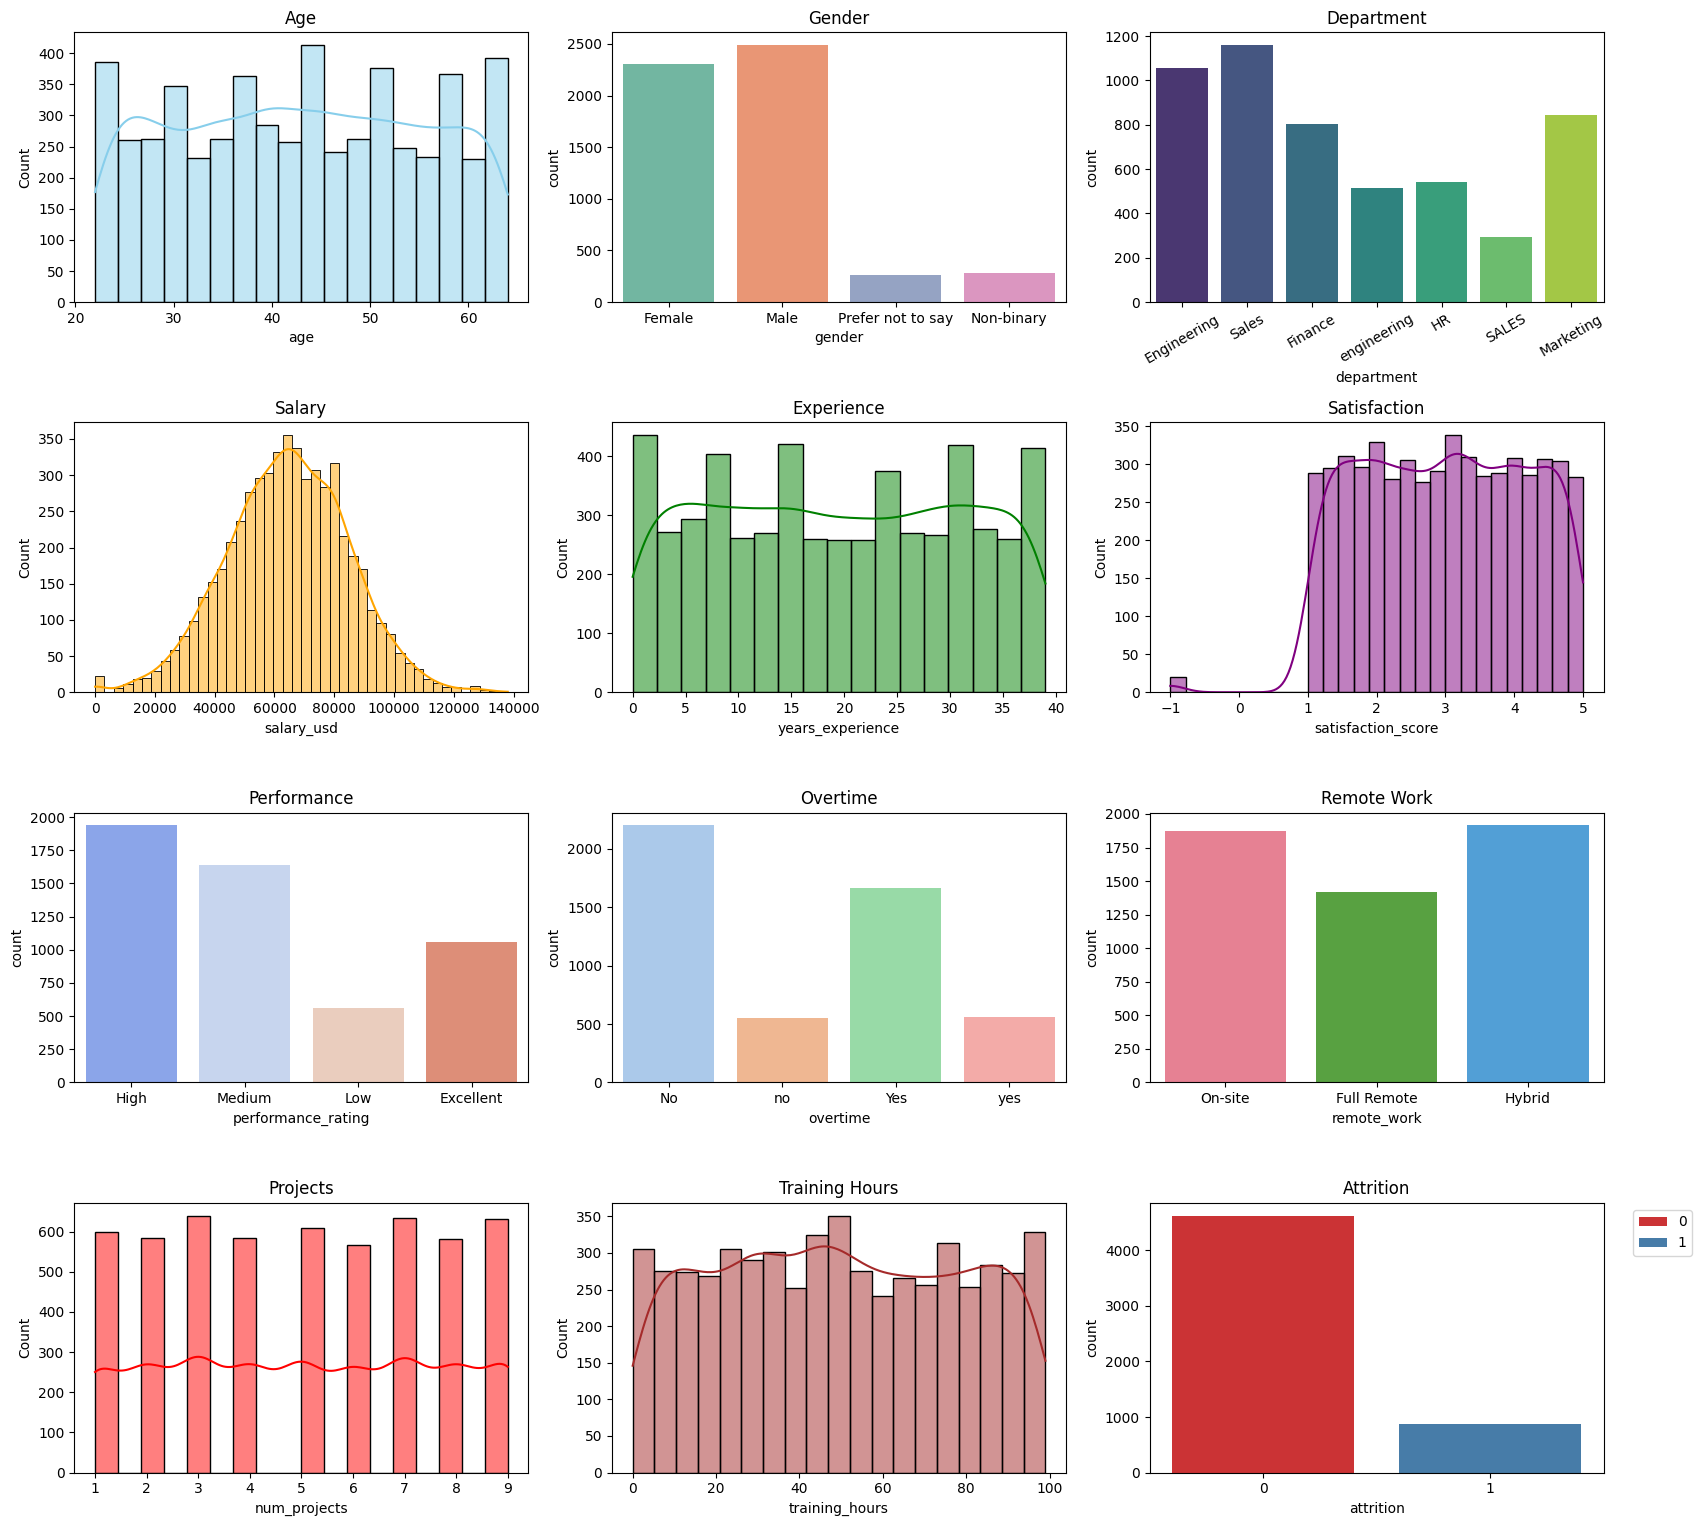

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

sns.histplot(df['age'], kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title("Age")

sns.countplot(x='gender', data=df, palette='Set2', ax=axes[0,1])
axes[0,1].set_title("Gender")

sns.countplot(x='department', data=df, palette='viridis', ax=axes[0,2])
axes[0,2].set_title("Department")
axes[0,2].tick_params(axis='x', rotation=30)

sns.histplot(df['salary_usd'], kde=True, color='orange', ax=axes[1,0])
axes[1,0].set_title("Salary")

sns.histplot(df['years_experience'], kde=True, color='green', ax=axes[1,1])
axes[1,1].set_title("Experience")

sns.histplot(df['satisfaction_score'], kde=True, color='purple', ax=axes[1,2])
axes[1,2].set_title("Satisfaction")

sns.countplot(x='performance_rating', data=df, palette='coolwarm', ax=axes[2,0])
axes[2,0].set_title("Performance")

sns.countplot(x='overtime', data=df, palette='pastel', ax=axes[2,1])
axes[2,1].set_title("Overtime")

sns.countplot(x='remote_work', data=df, palette='husl', ax=axes[2,2])
axes[2,2].set_title("Remote Work")

sns.histplot(df['num_projects'], kde=True, color='red', ax=axes[3,0])
axes[3,0].set_title("Projects")

sns.histplot(df['training_hours'], kde=True, color='brown', ax=axes[3,1])
axes[3,1].set_title("Training Hours")

sns.countplot(x='attrition', hue='attrition', data=df, palette='Set1', ax=axes[3,2])
axes[3,2].set_title("Attrition")
axes[3,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


### Bivariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3135493158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attrition', y='salary_usd', data=df, palette='cool', ax=axes[0,0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3135493158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attrition', y='years_experience', data=df, palette='Set3', ax=axes[0,1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2136\3135493158.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attrition', y='satisfaction_score', data=df, palette='Set2'

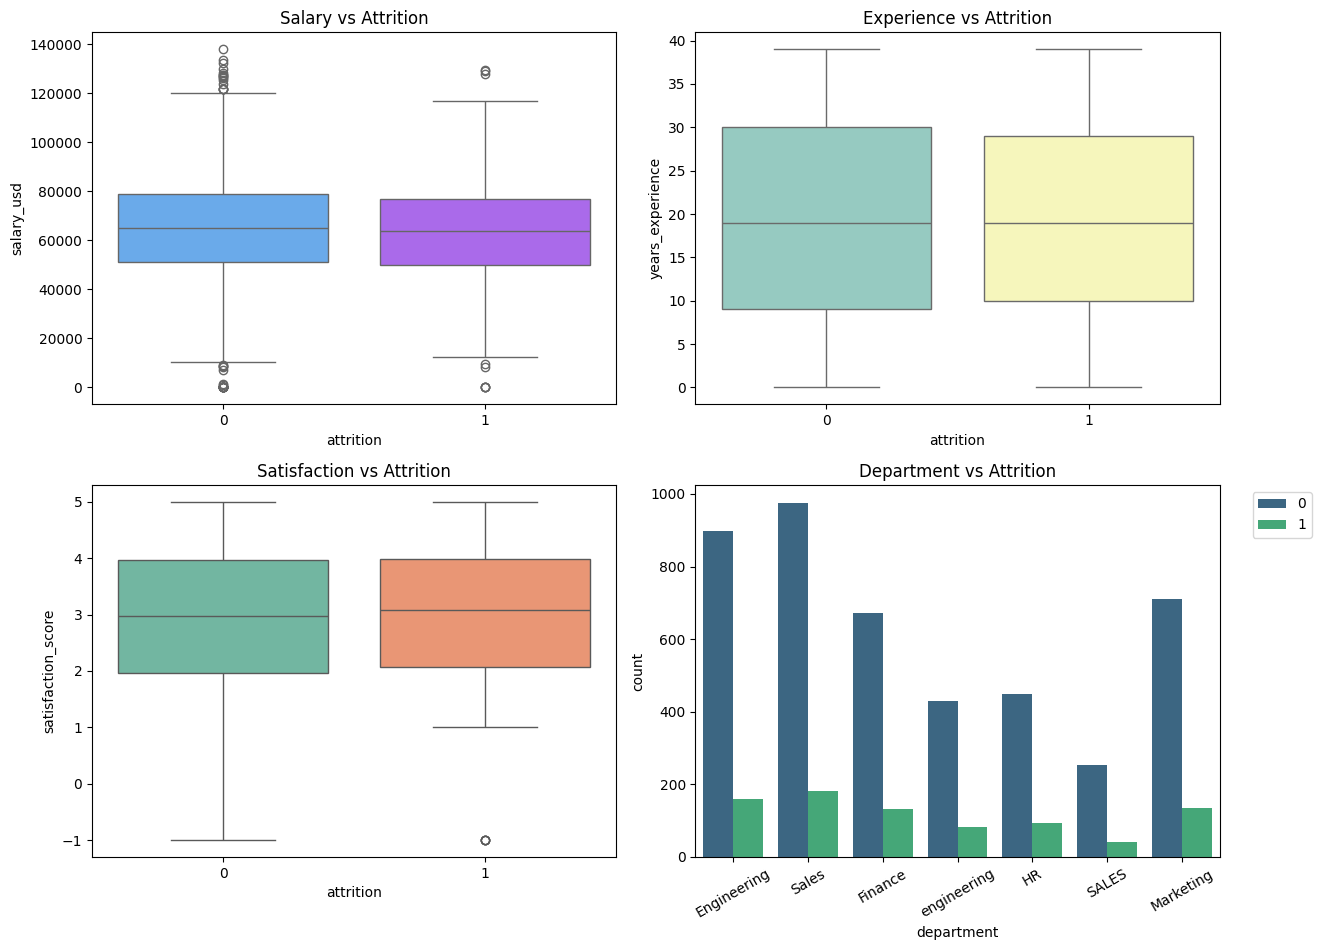

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='attrition', y='salary_usd', data=df, palette='cool', ax=axes[0,0])
axes[0,0].set_title("Salary vs Attrition")

sns.boxplot(x='attrition', y='years_experience', data=df, palette='Set3', ax=axes[0,1])
axes[0,1].set_title("Experience vs Attrition")

sns.boxplot(x='attrition', y='satisfaction_score', data=df, palette='Set2', ax=axes[1,0])
axes[1,0].set_title("Satisfaction vs Attrition")

sns.countplot(x='department', hue='attrition', data=df, palette='viridis', ax=axes[1,1])
axes[1,1].set_title("Department vs Attrition")
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

### Multivariate Analysis

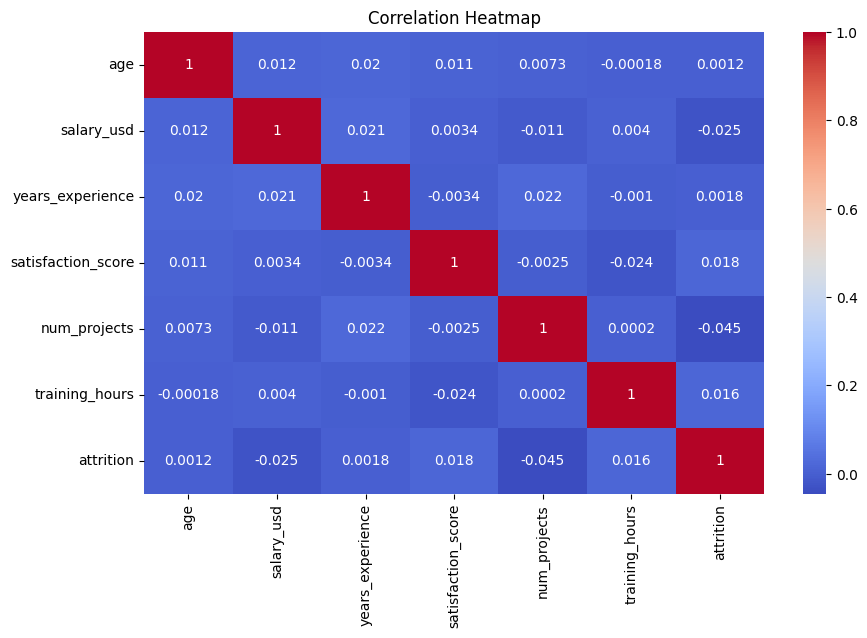

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Missing Value Identification and Dropping Unnecessary Features :

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

In [ ]:
df = df.drop(columns=['employee_id'])

In [ ]:
df.dtypes

## Checking Distribution : (Missing Numerical Feature Only)

In [ ]:
Missing_num = df[['age' , 'salary_usd' , 'years_experience', 'satisfaction_score',
                'num_projects','training_hours']]

Missing_cat = df[['gender' , 'department' , 'remote_work' , 'education_level','performance_rating','overtime']]

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['salary_usd'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Salary Distribution')

sns.histplot(df['years_experience'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Years Experience Distribution')

sns.histplot(df['satisfaction_score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Satisfaction Distribution')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['num_projects'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Projects Distribution')

sns.histplot(df['training_hours'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('training hours Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [ ]:
Imputing_num_cols = SimpleImputer(strategy= 'mean')
df['age'] = Imputing_num_cols.fit_transform(df[['age']])
df['salary_usd'] = Imputing_num_cols.fit_transform(df[['salary_usd']])
df['years_experience'] = Imputing_num_cols.fit_transform(df[['years_experience']])
df['satisfaction_score'] = Imputing_num_cols.fit_transform(df[['satisfaction_score']])
df['num_projects'] = Imputing_num_cols.fit_transform(df[['num_projects']])
df['training_hours'] = Imputing_num_cols.fit_transform(df[['training_hours']])

In [ ]:
def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['gender'] = random_impute(df['gender'])
df['department'] = random_impute(df['department'])
df['remote_work'] = random_impute(df['remote_work'])
df['education_level'] = random_impute(df['education_level'])
df['performance_rating'] = random_impute(df['performance_rating'])
df['overtime'] = random_impute(df['overtime'])


In [ ]:
df.isnull().sum()

## Re-Checking Distribution :

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(df['salary_usd'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Salary Distribution')

sns.histplot(df['years_experience'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Years Experience Distribution')

sns.histplot(df['satisfaction_score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Satisfaction Distribution')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['num_projects'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Projects Distribution')

sns.histplot(df['training_hours'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('training hours Distribution')

plt.tight_layout()
plt.show()

In [ ]:
df

## Feature Engineering , Outlier Handling & Encoding :

In [ ]:
df["department"] = df["department"].str.lower()
df["overtime"] = df["overtime"].str.lower()

In [ ]:
education_order = {
    "High School": 1,
    "Associate": 2,
    "Bachelor's": 3,
    "Master's": 4,
    "PhD": 5
}

df["education_level"] = df["education_level"].map(education_order)

In [ ]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High','Excellent']]
)

df['performance_rating'] = ordinal_encoder.fit_transform(df[['performance_rating']])

In [ ]:
df.head()

In [ ]:
onehot_cols = ["gender","department", "overtime", "remote_work"]

onehot_encoder = OneHotEncoder(drop='first',  sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df.index
)

df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)

In [ ]:
numeric_cols = [
    'age',
    'salary_usd',
    'years_experience',
    'satisfaction_score',
    'num_projects',
    'training_hours'
]

for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [ ]:
df["salary_usd"] = winsorize(
    df["salary_usd"],
    limits=[0.01, 0.01]
)

In [ ]:
df["satisfaction_score"] = df["satisfaction_score"].replace(-1, np.nan)

imputer = SimpleImputer(strategy="median")

df["satisfaction_score"] = imputer.fit_transform(
    df[["satisfaction_score"]]
)

In [ ]:
sns.boxplot(x=df['satisfaction_score'])
plt.show()

In [ ]:
sns.boxplot(x=df['salary_usd'])
plt.show()

In [ ]:
df['satisfaction_category'] = pd.cut(
    df['satisfaction_score'],
    bins=[0,2,3.5,5],
    labels=['Low','Medium','High']
)

In [ ]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High']]
)

df['satisfaction_category'] = ordinal_encoder.fit_transform(df[['satisfaction_category']])

## Feature Scaling :

In [ ]:
scale_cols = [ "age", "salary_usd", "years_experience", "satisfaction_score","num_projects","training_hours"]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [ ]:
df

In [ ]:
df["salary_per_experience"] = (
    df["salary_usd"] /
    (df["years_experience"] + 1)
)

df["workload_score"] = (
    df["num_projects"] *
    df["training_hours"]
)

df["productivity_score"] = (
    df["performance_rating"] *
    df["satisfaction_score"]
)

df

In [ ]:
Clean_dataset = df.copy()

Clean_dataset.head()